PLACEMENT STATUS DISTRIBUTION
PlacementStatus
Not Placed    100
Placed        100
Name: count, dtype: int64

TRAINING CLASSES
PlacementStatus
Not Placed    80
Placed        80
Name: count, dtype: int64

VALIDATION CLASSES
PlacementStatus
Not Placed    20
Placed        20
Name: count, dtype: int64


ADABOOST
Validation Accuracy: 0.925
Training Time: 0.2001 seconds

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.90      0.95      0.93        20
      Placed       0.95      0.90      0.92        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40



GRADIENT BOOSTING
Validation Accuracy: 0.85
Training Time: 0.142 seconds

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.85      0.85      0.85        20
      Placed       0.85      0.85      0.85        20

    accuracy        

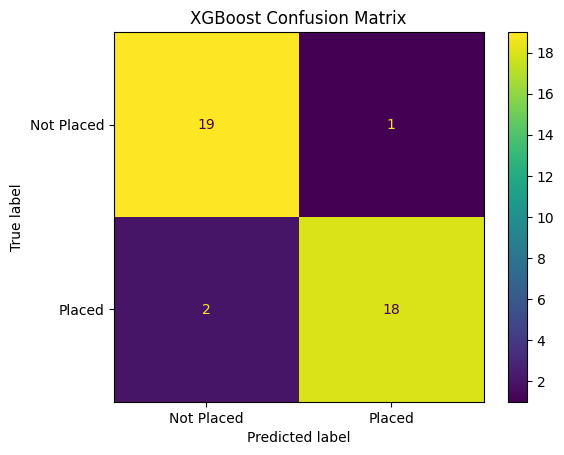



SHAP FEATURE IMPORTANCE


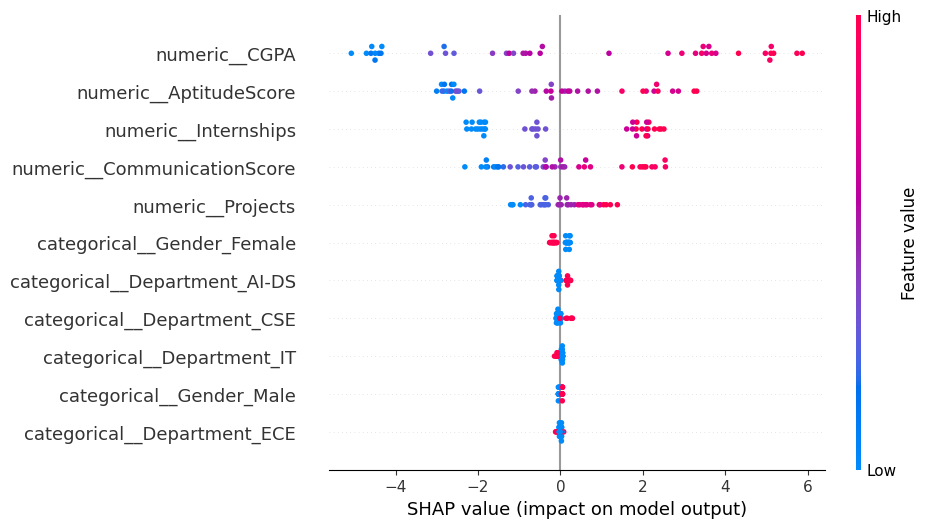



XGBOOST FEATURE IMPORTANCE
                      Feature  Importance
                numeric__CGPA    0.245304
  categorical__Department_CSE    0.129012
         numeric__Internships    0.122218
       numeric__AptitudeScore    0.107581
  numeric__CommunicationScore    0.091421
  categorical__Department_ECE    0.063874
            numeric__Projects    0.062159
categorical__Department_AI-DS    0.056976
   categorical__Department_IT    0.056874
   categorical__Gender_Female    0.034500
     categorical__Gender_Male    0.030081


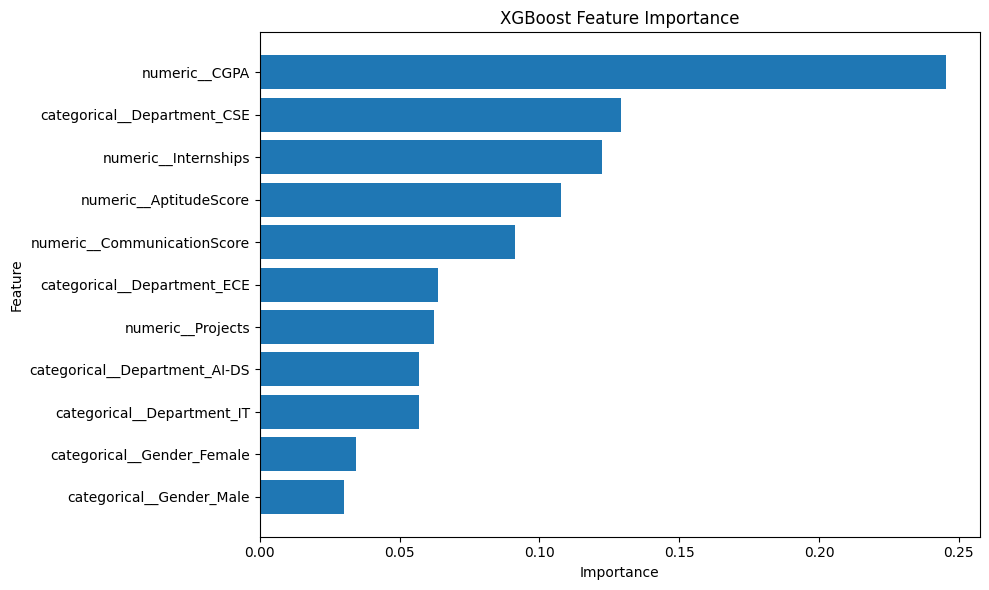



BOOSTING VERSION 1
Version 1 Accuracy: 0.95


BOOSTING VERSION 2
Version 2 Accuracy: 0.925


VERSION 1 VS VERSION 2
    Version  Validation Accuracy  Training Time
Boosting V1                0.950       0.201992
Boosting V2                0.925       0.604057


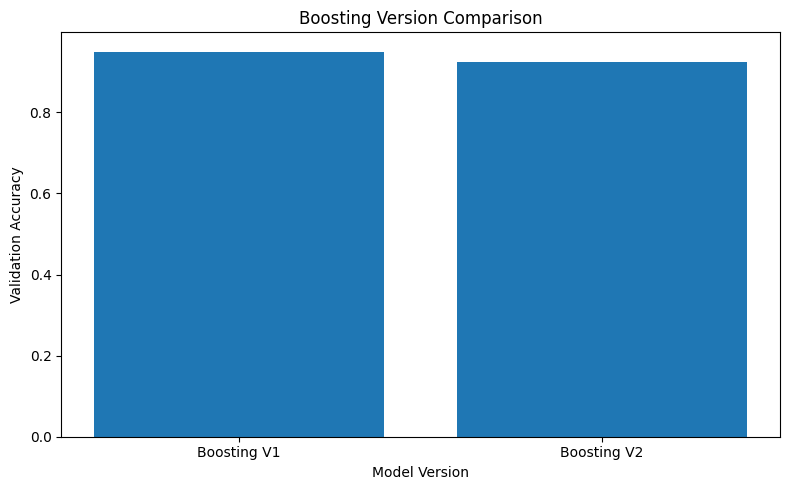



BOOSTING BENCHMARK RESULTS
            Model  Validation Accuracy  Training Time
         AdaBoost                0.925       0.305150
          XGBoost                0.925       0.141822
         LightGBM                0.925       0.018744
Gradient Boosting                0.850       0.208559


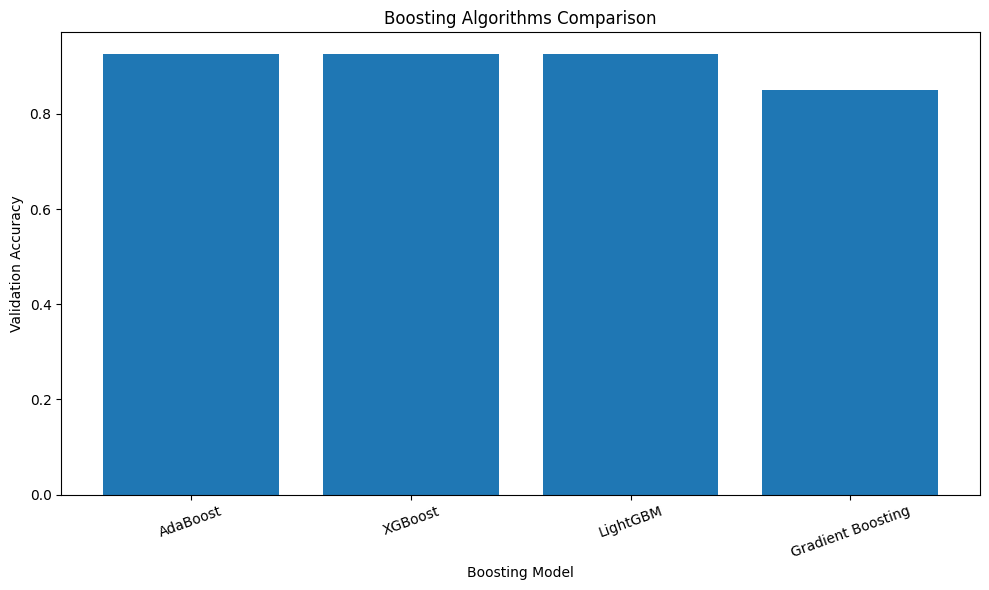



SESSION 8 COMPLETED SUCCESSFULLY
AdaBoost Accuracy: 0.925
Gradient Boosting Accuracy: 0.85
XGBoost Accuracy: 0.925
XGBoost Early Stopping Accuracy: 0.925
LightGBM Accuracy: 0.925

All Boosting Algorithms Executed Successfully.


In [103]:
# ============================================================
# SESSION 8 - BOOSTING ALGORITHMS
# AdaBoost | Gradient Boosting | XGBoost | LightGBM | SHAP
# FINAL CORRECTED VERSION
# ============================================================

# ============================================================
# 1. INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install -q xgboost lightgbm shap


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap


# ============================================================
# 3. CREATE STUDENT DATASET
# ============================================================

np.random.seed(42)

n = 200

df = pd.DataFrame({
    "CGPA": np.round(
        np.random.uniform(5.5, 9.8, n),
        2
    ),

    "AptitudeScore": np.random.randint(
        40, 100, n
    ),

    "CommunicationScore": np.random.randint(
        40, 100, n
    ),

    "Internships": np.random.randint(
        0, 4, n
    ),

    "Projects": np.random.randint(
        1, 6, n
    ),

    "Department": np.random.choice(
        ["CSE", "IT", "AI-DS", "ECE"],
        n
    ),

    "Gender": np.random.choice(
        ["Male", "Female"],
        n
    )
})


# ============================================================
# 4. CREATE PLACEMENT SCORE
# ============================================================

df["PlacementScore"] = (
    df["CGPA"] * 10
    + df["AptitudeScore"] * 0.5
    + df["CommunicationScore"] * 0.3
    + df["Internships"] * 5
    + df["Projects"] * 2
)


# ============================================================
# 5. CREATE BALANCED TARGET
# ============================================================

threshold = df["PlacementScore"].median()

df["PlacementStatus"] = np.where(
    df["PlacementScore"] >= threshold,
    "Placed",
    "Not Placed"
)


# ============================================================
# 6. CHECK TARGET DISTRIBUTION
# ============================================================

print("================================================")
print("PLACEMENT STATUS DISTRIBUTION")
print("================================================")

print(
    df["PlacementStatus"].value_counts()
)


# ============================================================
# 7. DEFINE FEATURES
# ============================================================

feature_cols = [
    "CGPA",
    "AptitudeScore",
    "CommunicationScore",
    "Internships",
    "Projects",
    "Department",
    "Gender"
]

X = df[feature_cols]

y = df["PlacementStatus"]


# ============================================================
# 8. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\n================================================")
print("TRAINING CLASSES")
print("================================================")

print(
    y_train.value_counts()
)


print("\n================================================")
print("VALIDATION CLASSES")
print("================================================")

print(
    y_val.value_counts()
)


# ============================================================
# 9. BINARY TARGET FOR XGBOOST AND LIGHTGBM
# ============================================================

y_train_binary = (
    y_train == "Placed"
).astype(int)

y_val_binary = (
    y_val == "Placed"
).astype(int)


# ============================================================
# 10. PREPROCESSOR
# ============================================================

numeric_features = [
    "CGPA",
    "AptitudeScore",
    "CommunicationScore",
    "Internships",
    "Projects"
]

categorical_features = [
    "Department",
    "Gender"
]


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)


# ============================================================
# 11. FIT PREPROCESSOR ONCE
# ============================================================

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_val_processed = preprocessor.transform(
    X_val
)


# ============================================================
# 12. FEATURE NAMES
# ============================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)


# ============================================================
# 13. CONVERT PROCESSED DATA TO DATAFRAME
#     This fixes the LightGBM warning.
# ============================================================

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_val_processed_df = pd.DataFrame(
    X_val_processed,
    columns=feature_names,
    index=X_val.index
)


# ============================================================
# 14. ADABOOST
# ============================================================

print("\n\n================================================")
print("ADABOOST")
print("================================================")

ada_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "classifier",
        AdaBoostClassifier(
            n_estimators=100,
            learning_rate=0.5,
            random_state=42
        )
    )
])


start_time = time.time()

ada_model.fit(
    X_train,
    y_train
)

ada_time = time.time() - start_time

ada_pred = ada_model.predict(
    X_val
)

ada_accuracy = accuracy_score(
    y_val,
    ada_pred
)


print(
    "Validation Accuracy:",
    round(ada_accuracy, 4)
)

print(
    "Training Time:",
    round(ada_time, 4),
    "seconds"
)

print("\nClassification Report:")

print(
    classification_report(
        y_val,
        ada_pred,
        zero_division=0
    )
)


# ============================================================
# 15. GRADIENT BOOSTING
# ============================================================

print("\n\n================================================")
print("GRADIENT BOOSTING")
print("================================================")

gbc_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "classifier",
        GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    )
])


start_time = time.time()

gbc_model.fit(
    X_train,
    y_train
)

gbc_time = time.time() - start_time

gbc_pred = gbc_model.predict(
    X_val
)

gbc_accuracy = accuracy_score(
    y_val,
    gbc_pred
)


print(
    "Validation Accuracy:",
    round(gbc_accuracy, 4)
)

print(
    "Training Time:",
    round(gbc_time, 4),
    "seconds"
)

print("\nClassification Report:")

print(
    classification_report(
        y_val,
        gbc_pred,
        zero_division=0
    )
)


# ============================================================
# 16. XGBOOST
# ============================================================

print("\n\n================================================")
print("XGBOOST")
print("================================================")

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=42,
    n_jobs=-1
)


start_time = time.time()

xgb_model.fit(
    X_train_processed_df,
    y_train_binary
)

xgb_time = time.time() - start_time


xgb_pred_binary = xgb_model.predict(
    X_val_processed_df
)

xgb_pred = np.where(
    xgb_pred_binary == 1,
    "Placed",
    "Not Placed"
)


xgb_accuracy = accuracy_score(
    y_val,
    xgb_pred
)


print(
    "Validation Accuracy:",
    round(xgb_accuracy, 4)
)

print(
    "Training Time:",
    round(xgb_time, 4),
    "seconds"
)

print("\nClassification Report:")

print(
    classification_report(
        y_val,
        xgb_pred,
        zero_division=0
    )
)


# ============================================================
# 17. XGBOOST WITH EARLY STOPPING
# ============================================================

print("\n\n================================================")
print("XGBOOST WITH EARLY STOPPING")
print("================================================")

xgb_early = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="logloss",

    early_stopping_rounds=30,

    random_state=42,
    n_jobs=-1
)


start_time = time.time()

xgb_early.fit(
    X_train_processed_df,
    y_train_binary,

    eval_set=[
        (
            X_val_processed_df,
            y_val_binary
        )
    ],

    verbose=False
)


xgb_early_time = (
    time.time() - start_time
)


xgb_early_pred_binary = (
    xgb_early.predict(
        X_val_processed_df
    )
)


xgb_early_pred = np.where(
    xgb_early_pred_binary == 1,
    "Placed",
    "Not Placed"
)


xgb_early_accuracy = (
    accuracy_score(
        y_val,
        xgb_early_pred
    )
)


print(
    "Best Iteration:",
    xgb_early.best_iteration
)

print(
    "Validation Accuracy:",
    round(
        xgb_early_accuracy,
        4
    )
)

print(
    "Training Time:",
    round(
        xgb_early_time,
        4
    ),
    "seconds"
)

print("\nClassification Report:")

print(
    classification_report(
        y_val,
        xgb_early_pred,
        zero_division=0
    )
)


# ============================================================
# 18. LIGHTGBM
# ============================================================

print("\n\n================================================")
print("LIGHTGBM")
print("================================================")

lgb_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    num_leaves=15,
    random_state=42,
    verbosity=-1
)


start_time = time.time()

# IMPORTANT:
# DataFrame with feature names is used here.
lgb_model.fit(
    X_train_processed_df,
    y_train_binary
)

lgb_time = (
    time.time() - start_time
)


lgb_pred_binary = (
    lgb_model.predict(
        X_val_processed_df
    )
)


lgb_pred = np.where(
    lgb_pred_binary == 1,
    "Placed",
    "Not Placed"
)


lgb_accuracy = (
    accuracy_score(
        y_val,
        lgb_pred
    )
)


print(
    "Validation Accuracy:",
    round(
        lgb_accuracy,
        4
    )
)

print(
    "Training Time:",
    round(
        lgb_time,
        4
    ),
    "seconds"
)

print("\nClassification Report:")

print(
    classification_report(
        y_val,
        lgb_pred,
        zero_division=0
    )
)


# ============================================================
# 19. CONFUSION MATRIX
# ============================================================

print("\n\n================================================")
print("XGBOOST CONFUSION MATRIX")
print("================================================")

cm = confusion_matrix(
    y_val,
    xgb_early_pred,

    labels=[
        "Not Placed",
        "Placed"
    ]
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,

    display_labels=[
        "Not Placed",
        "Placed"
    ]
)

disp.plot()

plt.title(
    "XGBoost Confusion Matrix"
)

plt.show()


# ============================================================
# 20. SHAP FEATURE IMPORTANCE
# ============================================================

print("\n\n================================================")
print("SHAP FEATURE IMPORTANCE")
print("================================================")

explainer = shap.TreeExplainer(
    xgb_early
)

shap_values = explainer(
    X_val_processed_df
)

shap_values.feature_names = (
    list(feature_names)
)


shap.plots.beeswarm(
    shap_values,
    max_display=15
)


# ============================================================
# 21. XGBOOST FEATURE IMPORTANCE
# ============================================================

print("\n\n================================================")
print("XGBOOST FEATURE IMPORTANCE")
print("================================================")


importance_df = pd.DataFrame({
    "Feature": feature_names,

    "Importance":
        xgb_early.feature_importances_
})


importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)


print(
    importance_df.to_string(
        index=False
    )
)


plt.figure(
    figsize=(10, 6)
)

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "XGBoost Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()


# ============================================================
# 22. BOOSTING VERSION 1
# ============================================================

print("\n\n================================================")
print("BOOSTING VERSION 1")
print("================================================")


gb_v1 = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "classifier",
        GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        )
    )
])


start_time = time.time()

gb_v1.fit(
    X_train,
    y_train
)

v1_time = (
    time.time() - start_time
)


v1_pred = gb_v1.predict(
    X_val
)


v1_accuracy = accuracy_score(
    y_val,
    v1_pred
)


print(
    "Version 1 Accuracy:",
    round(
        v1_accuracy,
        4
    )
)


# ============================================================
# 23. BOOSTING VERSION 2
# ============================================================

print("\n\n================================================")
print("BOOSTING VERSION 2")
print("================================================")


gb_v2 = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "classifier",
        GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            random_state=42
        )
    )
])


start_time = time.time()

gb_v2.fit(
    X_train,
    y_train
)

v2_time = (
    time.time() - start_time
)


v2_pred = gb_v2.predict(
    X_val
)


v2_accuracy = accuracy_score(
    y_val,
    v2_pred
)


print(
    "Version 2 Accuracy:",
    round(
        v2_accuracy,
        4
    )
)


# ============================================================
# 24. VERSION 1 VS VERSION 2
# ============================================================

version_df = pd.DataFrame({

    "Version": [
        "Boosting V1",
        "Boosting V2"
    ],

    "Validation Accuracy": [
        v1_accuracy,
        v2_accuracy
    ],

    "Training Time": [
        v1_time,
        v2_time
    ]
})


print("\n\n================================================")
print("VERSION 1 VS VERSION 2")
print("================================================")


print(
    version_df.to_string(
        index=False
    )
)


plt.figure(
    figsize=(8, 5)
)

plt.bar(
    version_df["Version"],
    version_df["Validation Accuracy"]
)

plt.xlabel(
    "Model Version"
)

plt.ylabel(
    "Validation Accuracy"
)

plt.title(
    "Boosting Version Comparison"
)

plt.tight_layout()

plt.show()


# ============================================================
# 25. BOOSTING BENCHMARK FUNCTION
# ============================================================

def boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
):

    results = []

    # --------------------------------------------------------
    # ADABOOST
    # --------------------------------------------------------

    ada = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            AdaBoostClassifier(
                n_estimators=100,
                learning_rate=0.5,
                random_state=42
            )
        )
    ])


    start = time.time()

    ada.fit(
        X_train,
        y_train
    )

    train_time = (
        time.time() - start
    )


    pred = ada.predict(
        X_val
    )


    acc = accuracy_score(
        y_val,
        pred
    )


    results.append({
        "Model": "AdaBoost",
        "Validation Accuracy": acc,
        "Training Time": train_time
    })


    # --------------------------------------------------------
    # GRADIENT BOOSTING
    # --------------------------------------------------------

    gbc = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ])


    start = time.time()

    gbc.fit(
        X_train,
        y_train
    )

    train_time = (
        time.time() - start
    )


    pred = gbc.predict(
        X_val
    )


    acc = accuracy_score(
        y_val,
        pred
    )


    results.append({
        "Model": "Gradient Boosting",
        "Validation Accuracy": acc,
        "Training Time": train_time
    })


    # --------------------------------------------------------
    # XGBOOST
    # --------------------------------------------------------

    xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,

        objective="binary:logistic",
        eval_metric="logloss",

        random_state=42,
        n_jobs=-1
    )


    start = time.time()

    xgb.fit(
        X_train_processed_df,
        y_train_binary
    )

    train_time = (
        time.time() - start
    )


    pred_binary = xgb.predict(
        X_val_processed_df
    )


    pred = np.where(
        pred_binary == 1,
        "Placed",
        "Not Placed"
    )


    acc = accuracy_score(
        y_val,
        pred
    )


    results.append({
        "Model": "XGBoost",
        "Validation Accuracy": acc,
        "Training Time": train_time
    })


    # --------------------------------------------------------
    # LIGHTGBM
    # --------------------------------------------------------

    lgb = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        num_leaves=15,
        random_state=42,
        verbosity=-1
    )


    start = time.time()

    lgb.fit(
        X_train_processed_df,
        y_train_binary
    )

    train_time = (
        time.time() - start
    )


    pred_binary = lgb.predict(
        X_val_processed_df
    )


    pred = np.where(
        pred_binary == 1,
        "Placed",
        "Not Placed"
    )


    acc = accuracy_score(
        y_val,
        pred
    )


    results.append({
        "Model": "LightGBM",
        "Validation Accuracy": acc,
        "Training Time": train_time
    })


    return (
        pd.DataFrame(results)
        .sort_values(
            "Validation Accuracy",
            ascending=False
        )
        .reset_index(drop=True)
    )


# ============================================================
# 26. RUN BENCHMARK
# ============================================================

benchmark_results = boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
)


print("\n\n================================================")
print("BOOSTING BENCHMARK RESULTS")
print("================================================")


print(
    benchmark_results.to_string(
        index=False
    )
)


# ============================================================
# 27. FINAL COMPARISON GRAPH
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    benchmark_results["Model"],
    benchmark_results["Validation Accuracy"]
)

plt.xlabel(
    "Boosting Model"
)

plt.ylabel(
    "Validation Accuracy"
)

plt.title(
    "Boosting Algorithms Comparison"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()


# ============================================================
# 28. FINAL RESULTS
# ============================================================

print("\n\n================================================")
print("SESSION 8 COMPLETED SUCCESSFULLY")
print("================================================")

print(
    "AdaBoost Accuracy:",
    round(ada_accuracy, 4)
)

print(
    "Gradient Boosting Accuracy:",
    round(gbc_accuracy, 4)
)

print(
    "XGBoost Accuracy:",
    round(xgb_accuracy, 4)
)

print(
    "XGBoost Early Stopping Accuracy:",
    round(xgb_early_accuracy, 4)
)

print(
    "LightGBM Accuracy:",
    round(lgb_accuracy, 4)
)

print(
    "\nAll Boosting Algorithms Executed Successfully."
)